<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session10: Polynomial Regression From Scratch</font></h3>
<h3 align="center">Zahra Amini</h3>

# Libraries

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import matplotlib

import copy
import math

# Data

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], 
                    [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [3]:
X_train

array([[0.5, 1.5],
       [1. , 1. ],
       [1.5, 0.5],
       [3. , 0.5],
       [2. , 2. ],
       [1. , 2.5]])

In [4]:
y_train

array([0, 0, 0, 1, 1, 1])

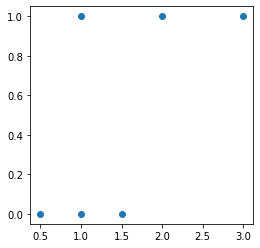

In [5]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))

plt.scatter(X_train[:, 0], y_train)

plt.show()

# Sigmoid

In [6]:
def sigmoid(z):
    
    g = 1/(1+np.exp(-z))
    
    return g

In [11]:
z_temp = np.arange(-10, 11)

y_z = sigmoid(z_temp)

np.set_printoptions(precision=3)
np.set_printoptions(formatter={'float_kind':'{:f}'.format})
print(np.c_[z_temp, y_z])

[[-10.000000 0.000045]
 [-9.000000 0.000123]
 [-8.000000 0.000335]
 [-7.000000 0.000911]
 [-6.000000 0.002473]
 [-5.000000 0.006693]
 [-4.000000 0.017986]
 [-3.000000 0.047426]
 [-2.000000 0.119203]
 [-1.000000 0.268941]
 [0.000000 0.500000]
 [1.000000 0.731059]
 [2.000000 0.880797]
 [3.000000 0.952574]
 [4.000000 0.982014]
 [5.000000 0.993307]
 [6.000000 0.997527]
 [7.000000 0.999089]
 [8.000000 0.999665]
 [9.000000 0.999877]
 [10.000000 0.999955]]


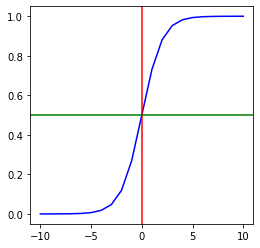

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(z_temp, y_z, c='b')

plt.axvline(x=0, color='r')

plt.axhline(0.5, color='g')
plt.show()

# Cost Function Logistic Regression

In [15]:
def cost_function(X, y, w, b):
    
    m = X.shape[0]
    cost = 0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb = sigmoid(z_i)
        
        cost += -y[i]* np.log(f_wb) - (1-y[i]) * np.log(1-f_wb)
        
    cost = cost/m
    
    return cost

# Gradient Descent

In [17]:
def gradient(X, y, w, b):
    
    m = X.shape[0]
    n = X.shape[1]
    
    dj_dw = np.zeros((n,))
    dj_db = 0
    
    for i in range(m):
        f_wb = sigmoid(np.dot(X[i], w) + b)
        
        loss = f_wb - y[i]
        
        for j in range(n):
            dj_dw[j] += loss* X[i, j]
        dj_db += loss
        
    dj_dw = dj_dw/m
    
    dj_db = dj_db/m
    
    return dj_dw, dj_db

In [18]:
w_init = np.array([0, 1])
b_init = 1
gradient(X_train, y_train, w_init, b_init)

(array([0.316298, 0.402742]), 0.39389162440250053)

# RUN Gradient Descent